# Progetto - Predict romantic compatibility

Il modello deve essere in grado di predire un score di compatibilità di una coppia. Questo progetto è un problema di regressione: il modello deve predire un numero: il score di compatibilità


# Setup

In [50]:
import sys

assert sys.version_info >= (3, 10)

In [51]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

In [52]:
import matplotlib.pyplot as plt

plt.rc('font', size=6)
plt.rc('axes', labelsize=6, titlesize=6)
plt.rc('legend', fontsize=6)
plt.rc('xtick', labelsize=6)
plt.rc('ytick', labelsize=6)

In [53]:

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Scaricare il dataset da Kaggle e importare le librerie

In [54]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")

print("Path to dataset files:", path)
print("Archivos:", os.listdir(path))
archivio = os.listdir(path)
csv_path = os.path.join(path, archivio[0])

Using Colab cache for faster access to the 'cupids-algorithm' dataset.
Path to dataset files: /kaggle/input/cupids-algorithm
Archivos: ['cupid_algorithm_dataset.csv']


# Quick look

Ciascuna riga rappresenta una coppia di individui (Persona A e Persona B) con 13 caratteristiche per persona, distribuite su 7 dimensioni.

* **Personality:** Tratti dei Big Five (apertura mentale, estroversione,
gradevolezza e coscienziosità), che descrivono il profilo psicologico. (noto anche con l'acronimo inglese OCEAN):O - Apertura all'esperienza (Openness): Curiosità, creatività e predisposizione verso nuove idee.C - Coscienziosità (Conscientiousness): Autocontrollo, precisione, affidabilità e orientamento agli obiettivi.E - Estroversione (Extraversion): Livello di energia, socievolezza e ricerca di stimoli esterni.A - Amicalità o Piacevolezza (Agreeableness): Altruismo, fiducia, empatia e capacità di cooperare.N - Nevroticismo o Stabilità Emotiva (Neuroticism): Tendenza a provare emozioni negative come ansia, instabilità e vulnerabilità
* **Career:** Settore professionale (10 settori) e livello di ambizione, che riflettono l'allineamento professionale.
* **Lifestyle:** Cronotipo (da nottambulo a mattiniero) e grado di spontaneità (da pianificatore a spirito libero).
* **Communication:** Espressività emotiva, che misura quanto apertamente gli individui condividono i propri sentimenti.
* **Love Language:** Modalità preferita di esprimere e ricevere affetto: Words of Affirmation, Acts of Service, Receiving Gifts, Quality Time oppure Physical Touch.
* **Demographics:** Età (18–55 anni), livello di istruzione (Scuola superiore → Dottorato) e tipologia di residenza (urbana, suburbana o rurale).

 informazioni generali sul dataset

In [55]:
df = pd.read_csv(csv_path)
df.head()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                

Nessun valore mancante o null

In [57]:
df.describe()

,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.558140,2.951980,0.496463,0.499959,0.500131,0.501397,0.498643,0.499697,0.500012,...,0.499897,0.499177,0.500100,0.500063,0.500779,0.500324,0.500310,63.122273,0.428810,68.906250
std,28867.657797,10.951788,1.117733,0.174898,0.223607,0.224783,0.223860,0.223444,0.224779,0.226265,...,0.223567,0.223989,0.223253,0.223312,0.224214,0.226398,0.225954,10.705780,0.494909,21.334574
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.500000,0.000000,0.000000
25%,25000.750000,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.320000,0.330000,0.330000,...,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,55.900000,0.000000,54.000000
50%,50000.500000,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,63.000000,0.000000,69.000000
75%,75000.250000,46.000000,4.000000,0.620000,0.670000,0.670000,0.680000,0.670000,0.670000,0.670000,...,0.670000,0.670000,0.670000,0.670000,0.680000,0.680000,0.670000,70.300000,1.000000,83.000000
max,100000.000000,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,120.000000


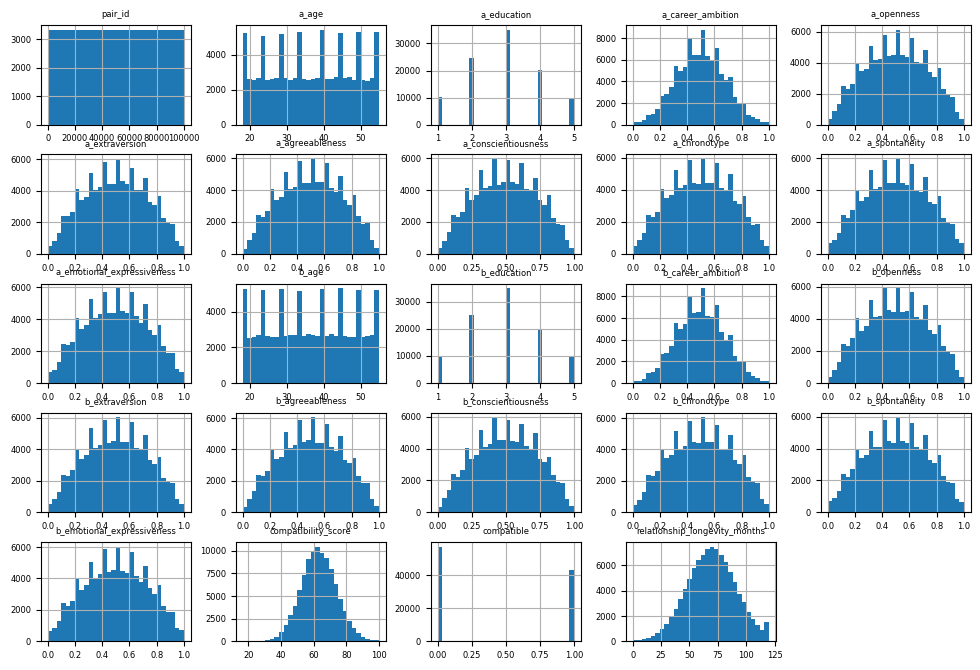

In [58]:
df.hist(bins=30, figsize=(12, 8))

plt.show()

# Train/test split

Splittiamo qui, subito dopo il primo sguardo generale ai dati (head/info/describe/istogrammi), e prima di qualsiasi analisi che metta in relazione le feature con il target (correlazioni, feature engineering). Da questo punto in avanti lavoriamo su una copia del solo train set, per evitare che l'esplorazione dei dati sia influenzata da osservazioni che poi finiranno nel test set (Data leakage).

In [59]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

df = train_set.copy()

Il target è `compatibilty_score`

Calcoliamo il coefficiente di correlazione di Pearson. La compatibilità dipende dalla relazione fra i due individui, non dal valore assoluto di uno solo. Quindi bisogna costruire delle variabili/feature che descrivano la relazione/differenza tra i traits tra le due persone della copia per posterioemnte calcolare la correlazione tra il punteggio dei tratits con lo score di compatibilità. Cioè identificare che feature aumentano o abassano il punteggio di compatibilità


Poiché il dataset descrive delle coppie e non individui singoli, le caratteristiche dei partner sono state trasformate in feature di compatibilità (ad esempio differenze assolute per le variabili numeriche e indicatori binari di uguaglianza per le variabili categoriche). In questo modo la correlazione viene calcolata tra caratteristiche della relazione e il compatibility_score, risultando molto più interpretabile rispetto alla correlazione tra le caratteristiche di un singolo individuo e il punteggio della coppia.

In [60]:
df["openness_diff"] = abs(df["a_openness"] - df["b_openness"])
df["career_ambition_diff"] = abs(df["a_career_ambition"] - df["b_career_ambition"])
df["extraversion_diff"] = abs(df["a_extraversion"] - df["b_extraversion"])
df["agreeableness_diff"] = abs(df["a_agreeableness"] - df["b_agreeableness"])
df["conscientiousness_diff"] = abs(df["a_conscientiousness"] - df["b_conscientiousness"])
df["chronotype_diff"] = abs(df["a_chronotype"] - df["b_chronotype"])
df["spontaneity_diff"] = abs(df["a_spontaneity"] - df["b_spontaneity"])
df["age_diff"] = abs(df["a_age"] - df["b_age"])
df["emotional_expressiveness_diff"] = abs(df["a_emotional_expressiveness"] - df["b_emotional_expressiveness"])
df["education_diff"] = abs(df["a_education"] - df["b_education"])


Oltre a confrontare le feature con punteggio (numerici), si vuole trovare un sistema per confrontare le condivisione dentro della coppia delle stesse variabile per classe, come il love language, il contesto residenza e il campo lavorativo

In [61]:
df["same_love_language"] = (
    df["a_love_language"] == df["b_love_language"]
).astype(int)

df["same_location"] = (
    df["a_location"] == df["b_location"]
).astype(int)

df["same_career"] = (
    df["a_career_field"] == df["b_career_field"]
).astype(int)



In [62]:
compatibility_features = [
    "age_diff",
    "education_diff",
    "career_ambition_diff",
    "openness_diff",
    "conscientiousness_diff",
    "extraversion_diff",
    "agreeableness_diff",
    "same_location",
    "same_career",
    "same_love_language"
]

corr = (
    df[compatibility_features]
      .corrwith(df["compatibility_score"])
      .sort_values(ascending=False)
)

corr = corr.to_frame(name="Pearson correlation")

print(corr)



                        Pearson correlation
same_love_language                 0.376429
same_career                        0.093638
same_location                      0.069708
age_diff                          -0.057268
agreeableness_diff                -0.081114
conscientiousness_diff            -0.085250
education_diff                    -0.086083
extraversion_diff                 -0.126357
openness_diff                     -0.129238
career_ambition_diff              -0.285526


Il coefficiente di Pearson varia tra -1 e +1: tra più il valore si avvicina a 1 dimostra una relazione lineare postiva, 0 indica che non c'è nessuna relazione e al avvicinarse a -1 se indica une relazione lineare negativa.

Dalla tabella risulta che la unica carateristica che una correlazione leve sulla compatibilità è il fatto di condividere lo stesso linguaggio del amore. Invece gran parte degli coeeficenti sono negativo, il cui indica che tra più grande sia la differenza della carateristica tra i componenti della copia minore risulterà il coefficente di compatibilità. Cioè più i partner sono diversi, menore sarà la compatibilità. Ma la correlazione è molto debole.

Le uniche due variabile che dimostrano un minimo di relazione lineale sono il linguaggio del amore e la ambizione lavorativa. I risultati nel suo compleso dimostrano che il Compatibility Score dipende da combinazioni di variabili, non da una singola caratteristica. per questo motivo il coefficente di person si confronterà con quello di Spearman, che lavora sui ranghi e potrebbe confermare le levi correlazione lineare o dimostrare delle correlazione molto più significative

In [63]:
pearson = df[compatibility_features].corrwith(
    df["compatibility_score"],
    method="pearson"
)

spearman = df[compatibility_features].corrwith(
    df["compatibility_score"],
    method="spearman"
)

results = pd.DataFrame({
    "Feature": compatibility_features,
    "Pearson (r)": pearson.values,
    "Spearman (ρ)": spearman.values
})


from scipy.stats import pearsonr, spearmanr
import pandas as pd

results = []

for feature in compatibility_features:

    # Pearson
    r, p_pearson = pearsonr(
        df[feature],
        df["compatibility_score"]
    )

    # Spearman
    rho, p_spearman = spearmanr(
        df[feature],
        df["compatibility_score"]
    )

    results.append({
        "Feature": feature,
        "Pearson (r)": r,
        "Spearman (ρ)": rho,
        "p-value Pearson": p_pearson,
        "p-value Spearman": p_spearman
    })


final_results = pd.DataFrame(results)

final_results

,Feature,Pearson (r),Spearman (ρ),p-value Pearson,p-value Spearman
0,age_diff,-0.057268,-0.060742,4.223851e-59,2.837856e-66
1,education_diff,-0.086083,-0.078655,2.032432e-131,5.633444e-110
2,career_ambition_diff,-0.285526,-0.275774,0.000000e+00,0.000000e+00
3,openness_diff,-0.129238,-0.116680,5.520816e-295,1.822542e-240
4,conscientiousness_diff,-0.085250,-0.079440,6.447023e-129,3.762569e-112
5,extraversion_diff,-0.126357,-0.113205,5.716198e-282,2.180467e-226
6,agreeableness_diff,-0.081114,-0.070951,7.378750e-117,8.510847e-90
7,same_location,0.069708,0.068074,9.756133e-87,8.498211e-83
8,same_career,0.093638,0.091160,3.108855e-155,3.384690e-147
9,same_love_language,0.376429,0.365351,0.000000e+00,0.000000e+00


Il confronto tra i coefficenti Pearsone Spearman dimostranno risultati molto similari dimostrando che il compatibility score è abbastanza stabile. In vece il P value calcolo in entrambi coefficenti indica una correlazione statisticamente significativa ma sempre devole, probabilmente influenza del campione molto grande.

Tutte le variabili analizzate mostrano correlazioni statisticamente significative con il compatibility_score (p < 0.001). Tuttavia, la magnitudine delle correlazioni varia considerevolmente. La maggiore associazione positiva è osservata per same_love_language, mentre career_ambition_diff mostra la relazione negativa più forte.

# Ricostruzione delle stesse feature sul test set

Il `test_set` è stato messo da parte al momento dello split e non ha ancora le colonne `_diff` e `same_*` create sopra. Le ricreiamo qui, con lo stesso codice usato per il train set, così che il test set sia coerente con il train set prima di valutare il modello.

In [64]:
test_set["openness_diff"] = abs(test_set["a_openness"] - test_set["b_openness"])
test_set["career_ambition_diff"] = abs(test_set["a_career_ambition"] - test_set["b_career_ambition"])
test_set["extraversion_diff"] = abs(test_set["a_extraversion"] - test_set["b_extraversion"])
test_set["agreeableness_diff"] = abs(test_set["a_agreeableness"] - test_set["b_agreeableness"])
test_set["conscientiousness_diff"] = abs(test_set["a_conscientiousness"] - test_set["b_conscientiousness"])
test_set["chronotype_diff"] = abs(test_set["a_chronotype"] - test_set["b_chronotype"])
test_set["spontaneity_diff"] = abs(test_set["a_spontaneity"] - test_set["b_spontaneity"])
test_set["age_diff"] = abs(test_set["a_age"] - test_set["b_age"])
test_set["emotional_expressiveness_diff"] = abs(test_set["a_emotional_expressiveness"] - test_set["b_emotional_expressiveness"])
test_set["education_diff"] = abs(test_set["a_education"] - test_set["b_education"])

test_set["same_love_language"] = (
    test_set["a_love_language"] == test_set["b_love_language"]
).astype(int)

test_set["same_location"] = (
    test_set["a_location"] == test_set["b_location"]
).astype(int)

test_set["same_career"] = (
    test_set["a_career_field"] == test_set["b_career_field"]
).astype(int)

# Separazione di X e y per train e test

Togliamo da `X` le colonne che non devono essere viste dal modello: `pair_id` (identificativo, non una feature), e le variabili target alternative (`compatible`, `relationship_longevity_months`) che altrimenti causerebbero data leakage.

In [65]:
train_set = df  # df contiene ora tutte le feature aggiunte durante l'EDA

escludere = ["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"]

X_train = train_set.drop(escludere, axis=1)
y_train = train_set["compatibility_score"]

X_test = test_set.drop(escludere, axis=1)
y_test = test_set["compatibility_score"]

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   a_age                          80000 non-null  int64  
 1   a_education                    80000 non-null  int64  
 2   a_location                     80000 non-null  object 
 3   a_career_field                 80000 non-null  object 
 4   a_career_ambition              80000 non-null  float64
 5   a_openness                     80000 non-null  float64
 6   a_extraversion                 80000 non-null  float64
 7   a_agreeableness                80000 non-null  float64
 8   a_conscientiousness            80000 non-null  float64
 9   a_chronotype                   80000 non-null  float64
 10  a_spontaneity                  80000 non-null  float64
 11  a_love_language                80000 non-null  object 
 12  a_emotional_expressiveness     80000 non-null  

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness",
    "openness_diff", "career_ambition_diff", "extraversion_diff",
    "agreeableness_diff", "conscientiousness_diff", "chronotype_diff",
    "spontaneity_diff", "age_diff", "emotional_expressiveness_diff", "education_diff",
    "same_love_language", "same_location", "same_career"
]

cat_features = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

Qui definiamo l'MLP per regressione.

```python
hidden_layer_sizes=[50, 50, 50]
```

significa che la rete ha tre hidden layer, ciascuno con 50 neuroni.

```python
early_stopping=True
```

fa sì che Scikit-Learn tenga da parte una porzione del training set come validation set interno e fermi l'addestramento quando la performance di validazione smette di migliorare.

In [67]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[100, 100, 100], early_stopping=True,
                       verbose=True, random_state=42)

In [68]:
pipeline = make_pipeline(preprocessing, mlp_reg)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 188.41096762
Validation score: 0.299421
Iteration 2, loss = 37.60997841
Validation score: 0.343864
Iteration 3, loss = 35.70382750
Validation score: 0.362274
Iteration 4, loss = 34.99807544
Validation score: 0.374474
Iteration 5, loss = 34.50306064
Validation score: 0.376599
Iteration 6, loss = 34.18989096
Validation score: 0.376238
Iteration 7, loss = 33.91060470
Validation score: 0.378911
Iteration 8, loss = 33.72562453
Validation score: 0.359636
Iteration 9, loss = 33.51103679
Validation score: 0.380788
Iteration 10, loss = 33.36552180
Validation score: 0.378760
Iteration 11, loss = 33.26832840
Validation score: 0.370865
Iteration 12, loss = 33.07641613
Validation score: 0.383848
Iteration 13, loss = 32.95333358
Validation score: 0.383960
Iteration 14, loss = 33.11469080
Validation score: 0.385689
Iteration 15, loss = 32.79918057
Validation score: 0.381968
Iteration 16, loss = 32.73757876
Validation score: 0.383165
Iteration 17, loss = 32.67534627
Validation scor

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['a_age', 'a_education',
                                                   'a_career_ambition',
                                                   'a_openness',
                                                   'a_extraversion',
                                                   'a_agreeableness',
                                                   'a_conscientiousness',
                                                   'a_chronotype',
                                                   'a_spontaneity',
                                                   'a_emotional_expressiveness',
                                                   'b_age', 'b_education',
                                                   'b_career_ambition',
                                                   'b_openness',
                                                   'b_extraversion',
                                                   'b_agreeable...
                                                   'chronotype_diff',
                                                   'spontaneity_diff',
                                                   'age_diff',
                                                   'emotional_expressiveness_diff',
                                                   'education_diff', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['a_location',
                                                   'a_career_field',
                                                   'a_love_language',
                                                   'b_location',
                                                   'b_career_field',
                                                   'b_love_language'])])),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True,
                              hidden_layer_sizes=[100, 100, 100],
                              random_state=42, verbose=True))])

## Learning curve del training

La `loss_curve_` mostra come cambia la loss durante l'addestramento.

Idealmente vogliamo vedere una diminuzione progressiva della loss. Con `early_stopping=True`, Scikit-Learn tiene anche una parte del training set come validation set interno e può fermare il training quando il modello smette di migliorare.

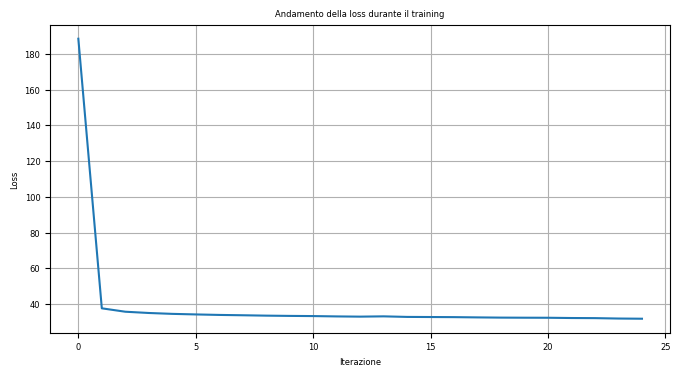

In [69]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_)
plt.xlabel("Iterazione")
plt.ylabel("Loss")
plt.title("Andamento della loss durante il training")
plt.grid(True)
plt.show()

## Andamento sul validation set

Con `early_stopping=True`, Scikit-Learn registra anche lo score sul validation set interno.

Questa curva aiuta a capire quando il modello sta migliorando su dati non usati direttamente per aggiornare i pesi.

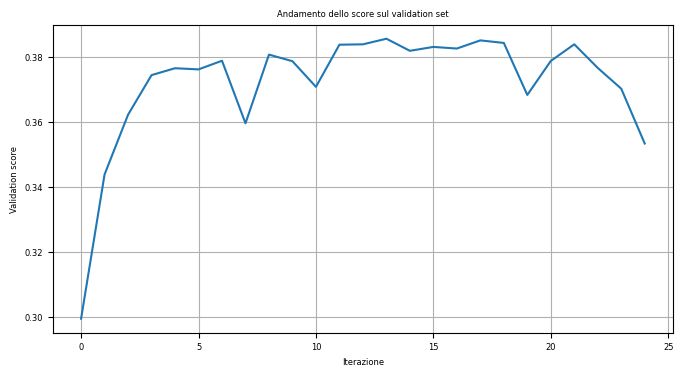

In [70]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.validation_scores_)
plt.xlabel("Iterazione")
plt.ylabel("Validation score")
plt.title("Andamento dello score sul validation set")
plt.grid(True)
plt.show()

`best_validation_score_` mostra il miglior punteggio ottenuto sul validation set interno durante l'addestramento.

È utile per capire se l'early stopping ha trovato una configurazione ragionevole prima di valutare il modello sul test set.

In [71]:
mlp_reg.best_validation_score_

0.3856889177618913

Ora valutiamo il modello sul test set usando l'**RMSE**.

L'RMSE è espresso nella stessa unità del target, quindi è più interpretabile del MSE come metrica finale.

In [72]:
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

8.24265298097708

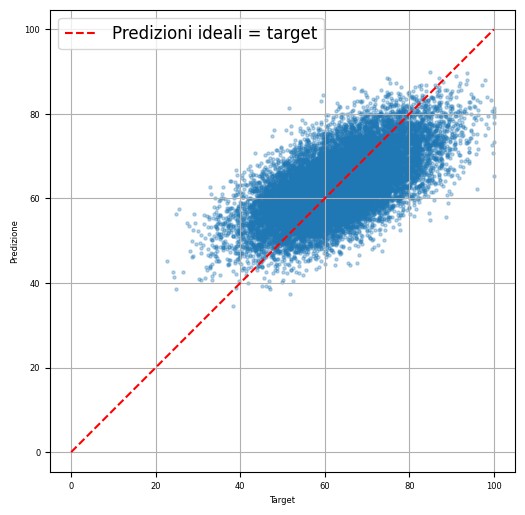

In [73]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
plt.plot([0, 100], [0, 100], color='red', linestyle='--',
         label="Predizioni ideali = target")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Predizione")
plt.legend(fontsize=12)
plt.grid()

plt.show()

# Decision tree

#Set up

In [74]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Stessa pipeline di preprocessing usata per l'MLP (StandardScaler + OneHotEncoder),
# così il confronto tra i due modelli è corretto: entrambi vedono gli stessi dati preparati allo stesso modo
tree_pipeline = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))

In [79]:
# Definiamo le combinazioni di parametri da provare per limitare la complessità dell'albero
# (senza limiti, un Decision Tree tende a "imparare a memoria" il train set = overfitting)
params = {
    'decisiontreeregressor__max_leaf_nodes': list(range(5, 50, 5)),   # numero massimo di foglie finali
    'decisiontreeregressor__max_depth': [1, 2, 3, 4, 5, 6],         # profondità massima dell'albero
    'decisiontreeregressor__min_samples_split': [2, 3, 4]           # minimo di righe per poter dividere un nodo
}

# GridSearchCV prova ogni combinazione di parametri usando cross-validation a 3 fold
# (divide il train set in 3 pezzi, si allena su 2 e valida sul terzo, a rotazione)
# tutto questo avviene SOLO dentro il train set, il test set resta intoccato
grid_search_cv = GridSearchCV(
    tree_pipeline,
    params,
    cv=3,
    scoring="neg_root_mean_squared_error",  # usiamo la stessa metrica (RMSE) del resto del progetto
     n_jobs=-1 )

grid_search_cv.fit(X_train, y_train)

print("Migliori parametri trovati:", grid_search_cv.best_params_)

Migliori parametri trovati: {'decisiontreeregressor__max_depth': 6, 'decisiontreeregressor__max_leaf_nodes': 45, 'decisiontreeregressor__min_samples_split': 2}


In [80]:
# GridSearchCV riallena automaticamente il modello migliore su tutto il train set (refit=True di default),
# quindi possiamo usarlo direttamente per predire sul test set
best_tree = grid_search_cv.best_estimator_

y_pred_tree = best_tree.predict(X_test)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)

print(f"RMSE Decision Tree (test): {rmse_tree:.3f}")
print(f"RMSE rete neurale MLP (test): {rmse:.3f}")  # rmse è già calcolato dalla sezione MLP

RMSE Decision Tree (test): 8.957
RMSE rete neurale MLP (test): 8.243


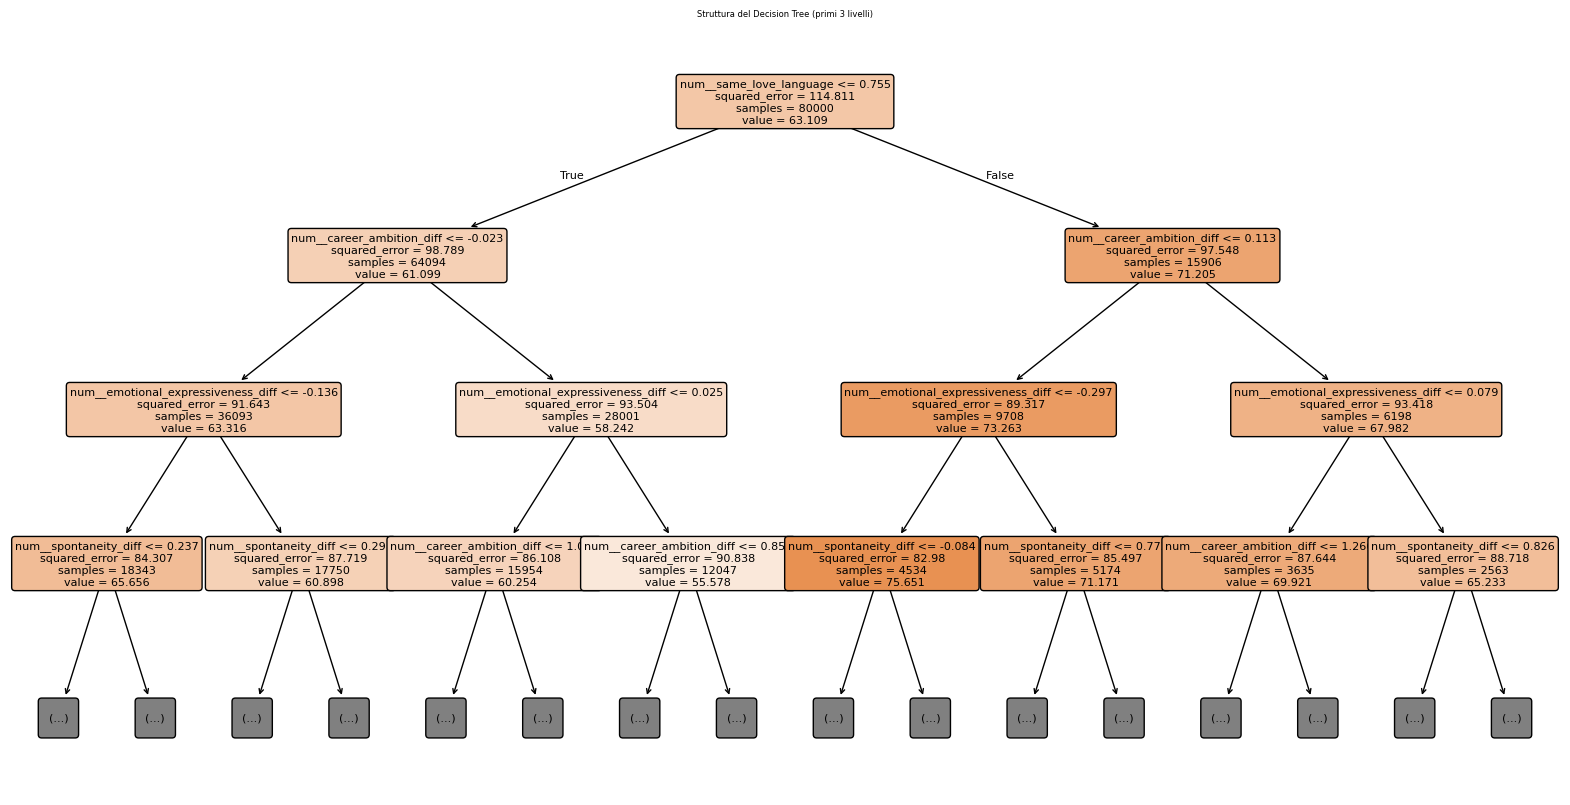

In [81]:
from sklearn.tree import plot_tree

# Estraiamo il Decision Tree vero e proprio dalla pipeline (il primo step è il preprocessing, il secondo è l'albero)
tree_model = best_tree.named_steps["decisiontreeregressor"]

# Recuperiamo i nomi delle colonne DOPO il preprocessing (dopo lo StandardScaler e il OneHotEncoder,
# perché il OneHotEncoder crea nuove colonne, una per ogni categoria)
feature_names = best_tree.named_steps["columntransformer"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,      # colora i nodi in base al valore predetto
    rounded=True,
    max_depth=3,       # mostra solo i primi 3 livelli, altrimenti con tante feature diventa illeggibile
                       # (l'albero vero puo' essere piu' profondo, questo limita solo il disegno)
    fontsize=8
)
plt.title("Struttura del Decision Tree (primi 3 livelli)")
plt.show()

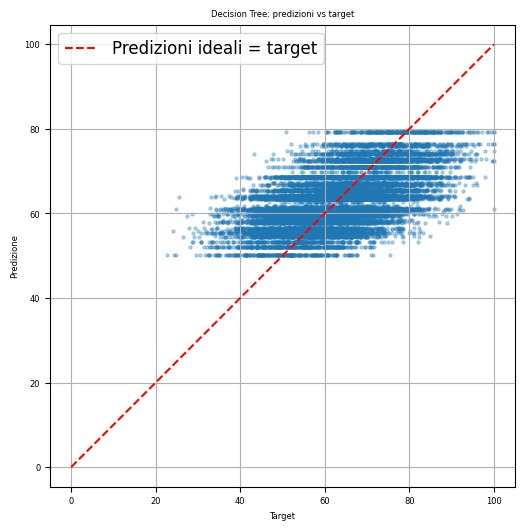

In [82]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tree, s=5, alpha=0.3)
plt.plot([0, 100], [0, 100], color='red', linestyle='--',
         label="Predizioni ideali = target")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Predizione")
plt.title("Decision Tree: predizioni vs target")
plt.legend(fontsize=12)
plt.grid()
plt.show()

In [83]:
from sklearn.metrics import mean_absolute_error, r2_score

# Per l'MLP
mae_mlp = mean_absolute_error(y_test, y_pred)
r2_mlp = r2_score(y_test, y_pred)

# Per il Decision Tree
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"{'Metrica':<10}{'MLP':>10}{'Decision Tree':>18}")
print(f"{'RMSE':<10}{rmse:>10.3f}{rmse_tree:>18.3f}")
print(f"{'MAE':<10}{mae_mlp:>10.3f}{mae_tree:>18.3f}")
print(f"{'R²':<10}{r2_mlp:>10.3f}{r2_tree:>18.3f}")

Metrica          MLP     Decision Tree
RMSE           8.243             8.957
MAE            6.570             7.130
R²             0.403             0.295


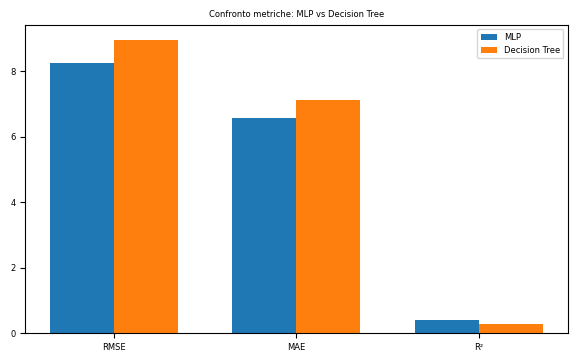

In [84]:
import numpy as np

metriche = ['RMSE', 'MAE', 'R²']
valori_mlp = [rmse, mae_mlp, r2_mlp]
valori_tree = [rmse_tree, mae_tree, r2_tree]

x = np.arange(len(metriche))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, valori_mlp, width, label='MLP')
plt.bar(x + width/2, valori_tree, width, label='Decision Tree')
plt.xticks(x, metriche)
plt.legend()
plt.title("Confronto metriche: MLP vs Decision Tree")
plt.show()